In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt 
from sklearn.datasets import make_circles
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
from IPython.display import clear_output, display
import time

## data preparation

In [2]:
X, y = make_circles(n_samples=1000, random_state=42, noise=.03)
print(X[0:5], "\n", y[0:5])

[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]] 
 [1 1 1 1 0]


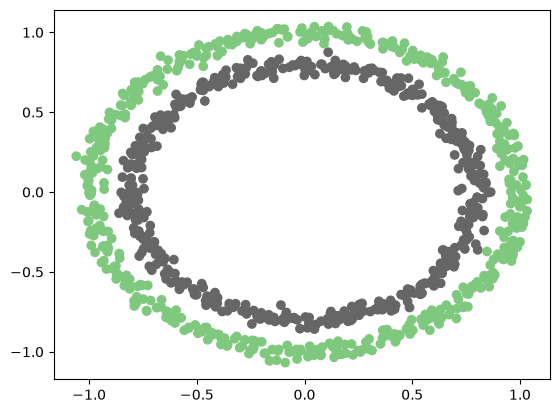

In [3]:
plt.Figure(figsize=(11, 7))
plt.scatter(x= X[:, 0], y=X[:, 1], c = y, cmap=plt.cm.Accent)
plt.show()

In [121]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [122]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)

In [123]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

## model creation

In [124]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [125]:
class ClassificationModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.tanh_1 = nn.Tanh()

        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.tanh_2 = nn.Tanh()

        self.layer_3 = nn.Linear(in_features=10, out_features=1)

    def forward(self, x):
        return self.layer_3(self.tanh_2(self.layer_2(self.tanh_1(self.layer_1(x)))))

classmodel_1 = ClassificationModel().to(device)

In [126]:
next(classmodel_1.parameters()).device

device(type='cuda', index=0)

In [127]:
classmodel_1.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.6213,  0.6595],
                      [-0.0298, -0.4515],
                      [ 0.3719, -0.4099],
                      [-0.6312, -0.6550],
                      [ 0.1367,  0.1657],
                      [ 0.6025, -0.5249],
                      [-0.3920, -0.3197],
                      [ 0.6385,  0.0171],
                      [ 0.2220, -0.1242],
                      [ 0.6720, -0.3420]], device='cuda:0')),
             ('layer_1.bias',
              tensor([-0.5650, -0.6441,  0.2592, -0.6291,  0.3668, -0.4546,  0.2897,  0.1314,
                       0.3580,  0.3339], device='cuda:0')),
             ('layer_2.weight',
              tensor([[-2.5212e-01,  2.9046e-01, -6.1881e-02, -2.0871e-01,  1.9887e-01,
                       -2.2700e-01, -5.8533e-02, -2.4586e-01, -2.5476e-01,  1.1521e-01],
                      [-2.1007e-01, -5.9725e-02, -1.6332e-01,  2.0081e-01, -9.1072e-02,
                       -4.7757e-02,  5.9826e-02

In [128]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(classmodel_1.parameters(), lr=.01)

In [129]:
def draw_boundary_on_ax(ax, model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor, title: str = ""):
    ax.clear()
    
    # Keep tensor computations on CPU for NumPy & Matplotlib compatibility
    X_cpu = X.cpu()
    y_cpu = y.cpu()
    
    x_min, x_max = X_cpu[:, 0].min() - 0.1, X_cpu[:, 0].max() + 0.1
    y_min, y_max = X_cpu[:, 1].min() - 0.1, X_cpu[:, 1].max() + 0.1
    xx, yy = np.meshgrid(
        np.linspace(x_min.item(), x_max.item(), 60),
        np.linspace(y_min.item(), y_max.item(), 60)
    )

    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float().to(device)

    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    if len(torch.unique(y_cpu)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))

    y_pred = y_pred.reshape(xx.shape).cpu().numpy()

    # Draw the boundary and scatter points
    ax.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    ax.scatter(X_cpu[:, 0], X_cpu[:, 1], c=y_cpu, s=40, cmap=plt.cm.RdYlBu, edgecolors="k", linewidth=0.5)
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_title(title)

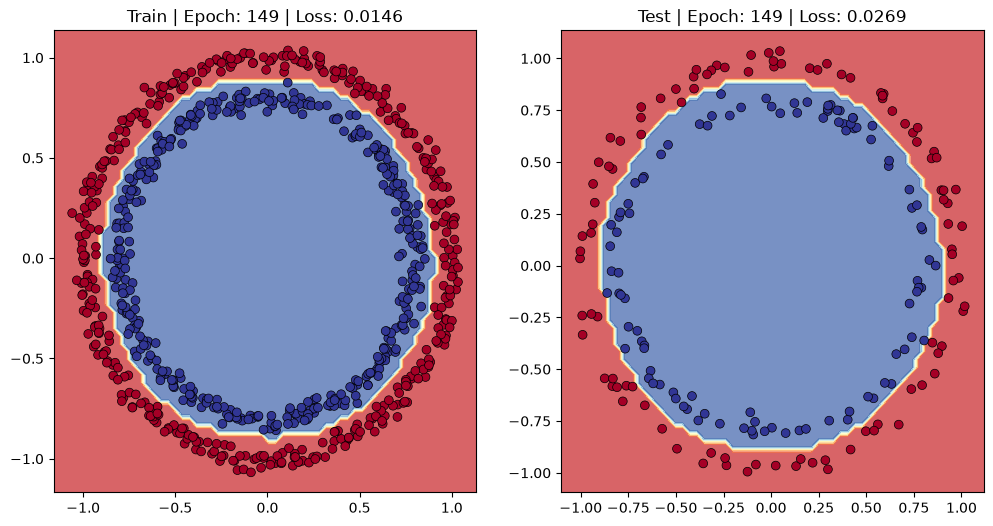

In [130]:
epochs = 150
train_loss_list = []
test_loss_list = []
update_interval = 1

fig, (ax_train, ax_test) = plt.subplots(1, 2, figsize=(12, 6))

for epoch in range(epochs):
    classmodel_1.train()

    optimizer.zero_grad()

    y_pred = classmodel_1(X_train.to(device))

    train_loss = loss_fn(y_pred.squeeze(), y_train.to(device))
    train_loss_list.append(train_loss.cpu().detach().numpy())

    train_loss.backward()

    optimizer.step()

    if epoch % update_interval == 0 or epoch == epochs - 1:
        start_time = time.perf_counter()
        classmodel_1.eval()

        with torch.inference_mode():
            test_pred = classmodel_1(X_test.to(device))
            test_loss = loss_fn(test_pred.squeeze(), y_test.to(device))
            test_loss_list.append(test_loss.cpu().numpy())

            draw_boundary_on_ax(
            ax_train, classmodel_1, X_train, y_train, 
            title=f"Train | Epoch: {epoch} | Loss: {train_loss.item():.4f}"
        )
            draw_boundary_on_ax(
                ax_test, classmodel_1, X_test, y_test, 
                title=f"Test | Epoch: {epoch} | Loss: {test_loss.item():.4f}"
            )

            # Clear previous frame and display the updated figure
            clear_output(wait=True)
            display(fig)

            elapsed = time.perf_counter() - start_time
            remaining_time = .004 - elapsed
            if remaining_time > 0:
                time.sleep(remaining_time)
plt.close(fig)

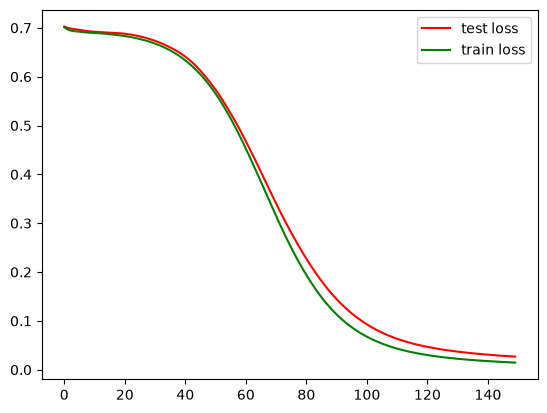

In [131]:
def loss_plot(test_loss_list = test_loss_list, train_loss_list = train_loss_list):
    plt.Figure(figsize=(10,7))
    plt.plot(test_loss_list, c="red", label= "test loss")
    plt.plot(train_loss_list, c="green", label= "train loss")
    plt.legend()
    plt.show()

loss_plot()

In [132]:
# Correct way to evaluate logits:
train_preds = torch.round(torch.sigmoid(y_pred)).squeeze().cpu().detach().numpy()
test_preds = torch.round(torch.sigmoid(test_pred)).squeeze().cpu().numpy()

print(f"Train Acc: {accuracy_score(y_train.cpu().numpy(), train_preds)}")
print(f"Test Acc:  {accuracy_score(y_test.cpu().numpy(), test_preds)}")

Train Acc: 1.0
Test Acc:  1.0


In [133]:
def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.

    Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)
    """
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) 
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  

    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

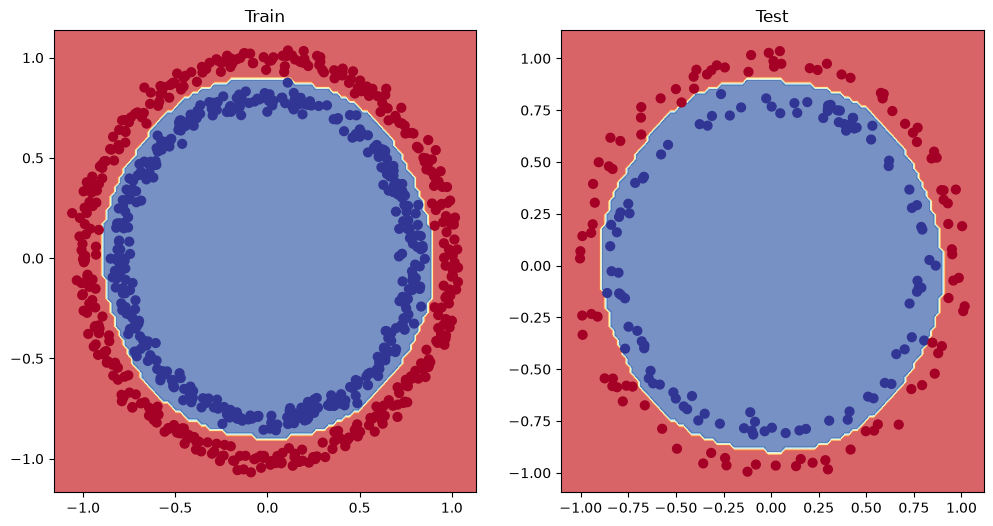

In [134]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(classmodel_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(classmodel_1, X_test, y_test)